# Play-style Distribution & Clustering of the 5 AI Archetypes

**Data.** `log/<style>_AggroPirateWarrior/` holds 5 folders. Every folder is the **same**
`AggroPirateWarrior` deck, but driven by a different SabberStone search/AI play-style:
**aggro · control · fatigue · midrange · ramp**. In each log the folder's style is **P1 (me)**;
the opponent (deck *and* style) varies across ~840 games per folder. We measure **P1 only** and
**pool over all opponents** (per the chosen scope).

**Method** — same spirit as `warrior_top20_rank5to10_byGames_analysis.ipynb`: parse each game into a
tidy per-game table, then study the **statistical distribution** of play-style metrics. Here each
*"player"* of the reference becomes one of the **5 style folders**, and we ask whether the
distributions form **5 clusters**.

**Metrics** include the reference's tempo/mana family **plus new play-style metrics** (hero-power rate,
face-damage rate, *face-vs-trade* attack ratio, attacks/turn, damage taken, card cost) and — as
requested — **average number of cards in hand** (mean hand size at the end of each of my turns).

> **Headline finding (quantified below).** A single game is too noisy to cluster — the same deck plus
> random opponents makes per-game points overlap (KMeans ARI ≈ 0). But a *play-style is a distribution
> over games*, not one game. Once we look at the **distribution / aggregated fingerprint**, the **5
> clusters separate cleanly** (cluster-vs-style ARI climbs to ≈ 0.87). Both views are shown honestly.

## 1 · Setup & parse

The parser lives in [`playstyle_log_parse.py`](playstyle_log_parse.py) (single source of truth, unit-tested
on individual games). It reads every verbose log, attributes events to **P1** by entity id
(`PlayCardTask => [P1]`, `PayPhase 'card[id]'`, `HeroPowerTask`, hero-entity ids for face damage), and
joins each folder's `summary.csv` for the header facts (winner, turns, seconds, start player).
Results are cached to `playstyle_log_metrics.pkl` — delete it to force a full re-parse.

In [33]:
import os, sys, pickle, collections, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
# Make the parser importable and anchor every data path to the repo root, no matter
# where the kernel's CWD starts (VSCode/Jupyter may use the repo root OR this folder).
def _repo_root():
    """Nearest ancestor of the CWD that holds both Log_Analysis/ and log/."""
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "Log_Analysis")) and os.path.isdir(os.path.join(d, "log")):
            return d
        if os.path.basename(d) == "Log_Analysis":
            return os.path.dirname(d)
        parent = os.path.dirname(d)
        if parent == d:
            raise FileNotFoundError("repo root with Log_Analysis/ and log/ not found from " + os.getcwd())
        d = parent
sys.path.insert(0, os.path.join(_repo_root(), "Log_Analysis", "V1"))
from playstyle_log_parse import build_frames, STYLES, BASE_DIR

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

# stable order + one colour per play-style (used everywhere)
STYLE_ORDER  = ["aggro", "control", "fatigue", "midrange", "ramp"]
STYLE_COLORS = dict(zip(STYLE_ORDER, ["#d62728", "#1f77b4", "#9467bd", "#2ca02c", "#ff7f0e"]))
PALETTE      = [STYLE_COLORS[s] for s in STYLE_ORDER]

CACHE = os.path.join(BASE_DIR, "playstyle_log_metrics.pkl")
games_df, cards_df, turns_df = build_frames(cache=CACHE)
# NB: 'style' clashes with the DataFrame.style accessor -> always index with games_df["style"]
games_df["style"] = pd.Categorical(games_df["style"], categories=STYLE_ORDER, ordered=True)

print(f"games_df {games_df.shape} | cards_df {cards_df.shape} | turns_df {turns_df.shape}")
print("\ngames per style:")
print(games_df["style"].value_counts().reindex(STYLE_ORDER).to_string())
print(f"\noverall P1 win rate: {games_df['win'].mean():.1%}")
games_df.head(3)

games_df (4213, 35) | cards_df (37135, 3) | turns_df (30445, 4)

games per style:
style
aggro       846
control     846
fatigue     846
midrange    840
ramp        835

overall P1 win rate: 62.0%


,style,game_id,log_file,opp_style,opp_deck,opp_class,win,start_player,duration,turns,...,coin_turn,hp_uses,hp_per_turn,face_dmg,face_dmg_per_turn,taken_dmg,attacks_per_turn,face_attack_ratio,avg_cards_in_hand,max_cards_in_hand
0,aggro,1,game_001_aggro-AggroPirateWarrior_vs_aggro-Agg...,aggro,AggroPirateWarrior,WARRIOR,False,1,0.60,10,...,NaN,0,0.0,14,2.800000,31,0.400000,1.000000,8.200000,10
1,aggro,1,game_001_aggro-AggroPirateWarrior_vs_aggro-Mid...,aggro,MidrangeBuffPaladin,PALADIN,True,2,1.08,12,...,3.0,0,0.0,34,5.666667,21,1.833333,0.909091,3.166667,4
2,aggro,1,game_001_aggro-AggroPirateWarrior_vs_aggro-Mid...,aggro,MidrangeJadeShaman,SHAMAN,True,1,0.43,13,...,NaN,0,0.0,30,4.285714,9,1.571429,0.545455,3.714286,5


### 1b · Metric glossary

All metrics are for **P1 (the folder's play-style)**, one value per game. *New* = beyond the reference set.

| metric (column) | meaning | new? |
|---|---|---|
| `n_my_turns` | number of P1 turns played | |
| `time_per_turn` | engine seconds per turn (search effort) | ✓ |
| `cards_per_turn` | non-Coin cards played per turn | |
| `minions_per_turn` | minions played per turn | ✓ |
| `mana_eff` | mana spent ÷ mana available | |
| `mana_per_turn` | mana spent per turn | |
| `avg_card_cost` | mean mana cost of cards P1 played (curve centre) | |
| `first_turn` | first P1 turn a card is played | |
| `coin_turn` | P1 turn the Coin is played (NaN if none) | |
| **`avg_cards_in_hand`** | **mean hand size at the end of each P1 turn** | **✓ (requested)** |
| `max_cards_in_hand` | peak hand size in the game | ✓ |
| `hp_per_turn` | hero-power activations per turn | ✓ |
| `face_dmg_per_turn` | damage dealt to the enemy hero per turn (aggression) | ✓ |
| `face_attack_ratio` | share of P1 attacks aimed at the enemy **face** vs minions | ✓ |
| `attacks_per_turn` | P1 attacks per turn | ✓ |
| `taken_dmg` | total damage P1's hero took (game) | ✓ |

## 2 · Per-style distribution grids

One distribution grid **per style folder** — the direct analogue of the reference's `show_player()`.
Dashed line = that style's mean. Eyeball how the shapes shift from **aggro** (short games, high face
ratio, low hand) toward **ramp / control** (longer games, more trading, more hero-power).

In [34]:
# label -> (column, kind);  kind drives the plot style
METRICS = {
    "My turns / game":     ("n_my_turns",        "disc"),
    "Time / turn (s)":     ("time_per_turn",     "kde"),
    "Cards / turn":        ("cards_per_turn",    "kde"),
    "Minions / turn":      ("minions_per_turn",  "kde"),
    "Mana efficiency":     ("mana_eff",          "clip01"),
    "Mana spent / turn":   ("mana_per_turn",     "kde"),
    "Avg card cost":       ("avg_card_cost",     "kde"),
    "First turn to play":  ("first_turn",        "disc"),
    "Avg cards in hand":   ("avg_cards_in_hand", "kde"),
    "Max cards in hand":   ("max_cards_in_hand", "disc"),
    "Hero-power / turn":   ("hp_per_turn",       "kde"),
    "Face dmg / turn":     ("face_dmg_per_turn", "kde"),
    "Face-attack ratio":   ("face_attack_ratio", "clip01"),
    "Attacks / turn":      ("attacks_per_turn",  "kde"),
    "Damage taken (game)": ("taken_dmg",         "kde"),
}
FEATURES = [c for _, (c, _) in METRICS.items()]   # numeric columns used for clustering

def _plot_metric(ax, s, kind, color):
    s = s.dropna()
    if not len(s):
        return
    if kind == "disc":
        sns.histplot(s.round().astype(int), discrete=True, color=color, ax=ax, stat="density")
    elif kind == "clip01":
        sns.histplot(s.clip(0, 1), kde=(s.nunique() > 1), color=color, ax=ax, stat="density")
    else:
        sns.histplot(s, kde=(s.nunique() > 1), color=color, ax=ax, stat="density")
    ax.axvline(s.mean(), color="k", ls="--", lw=1)

def show_style(style):
    gp = games_df[games_df["style"] == style]
    display(Markdown(
        f"### `{style}`  ·  {len(gp)} games  ·  win {gp['win'].mean():.1%}  ·  "
        f"avg {gp['n_my_turns'].mean():.1f} turns"))
    fig, axes = plt.subplots(3, 5, figsize=(19, 9)); axes = axes.ravel()
    for ax, (label, (col, kind)) in zip(axes, METRICS.items()):
        _plot_metric(ax, gp[col], kind, STYLE_COLORS[style])
        ax.set_title(label, fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")
    fig.suptitle(f"{style} — per-game metric distributions", fontsize=14, color=STYLE_COLORS[style])
    fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

### `aggro`  ·  846 games  ·  win 52.7%  ·  avg 6.5 turns

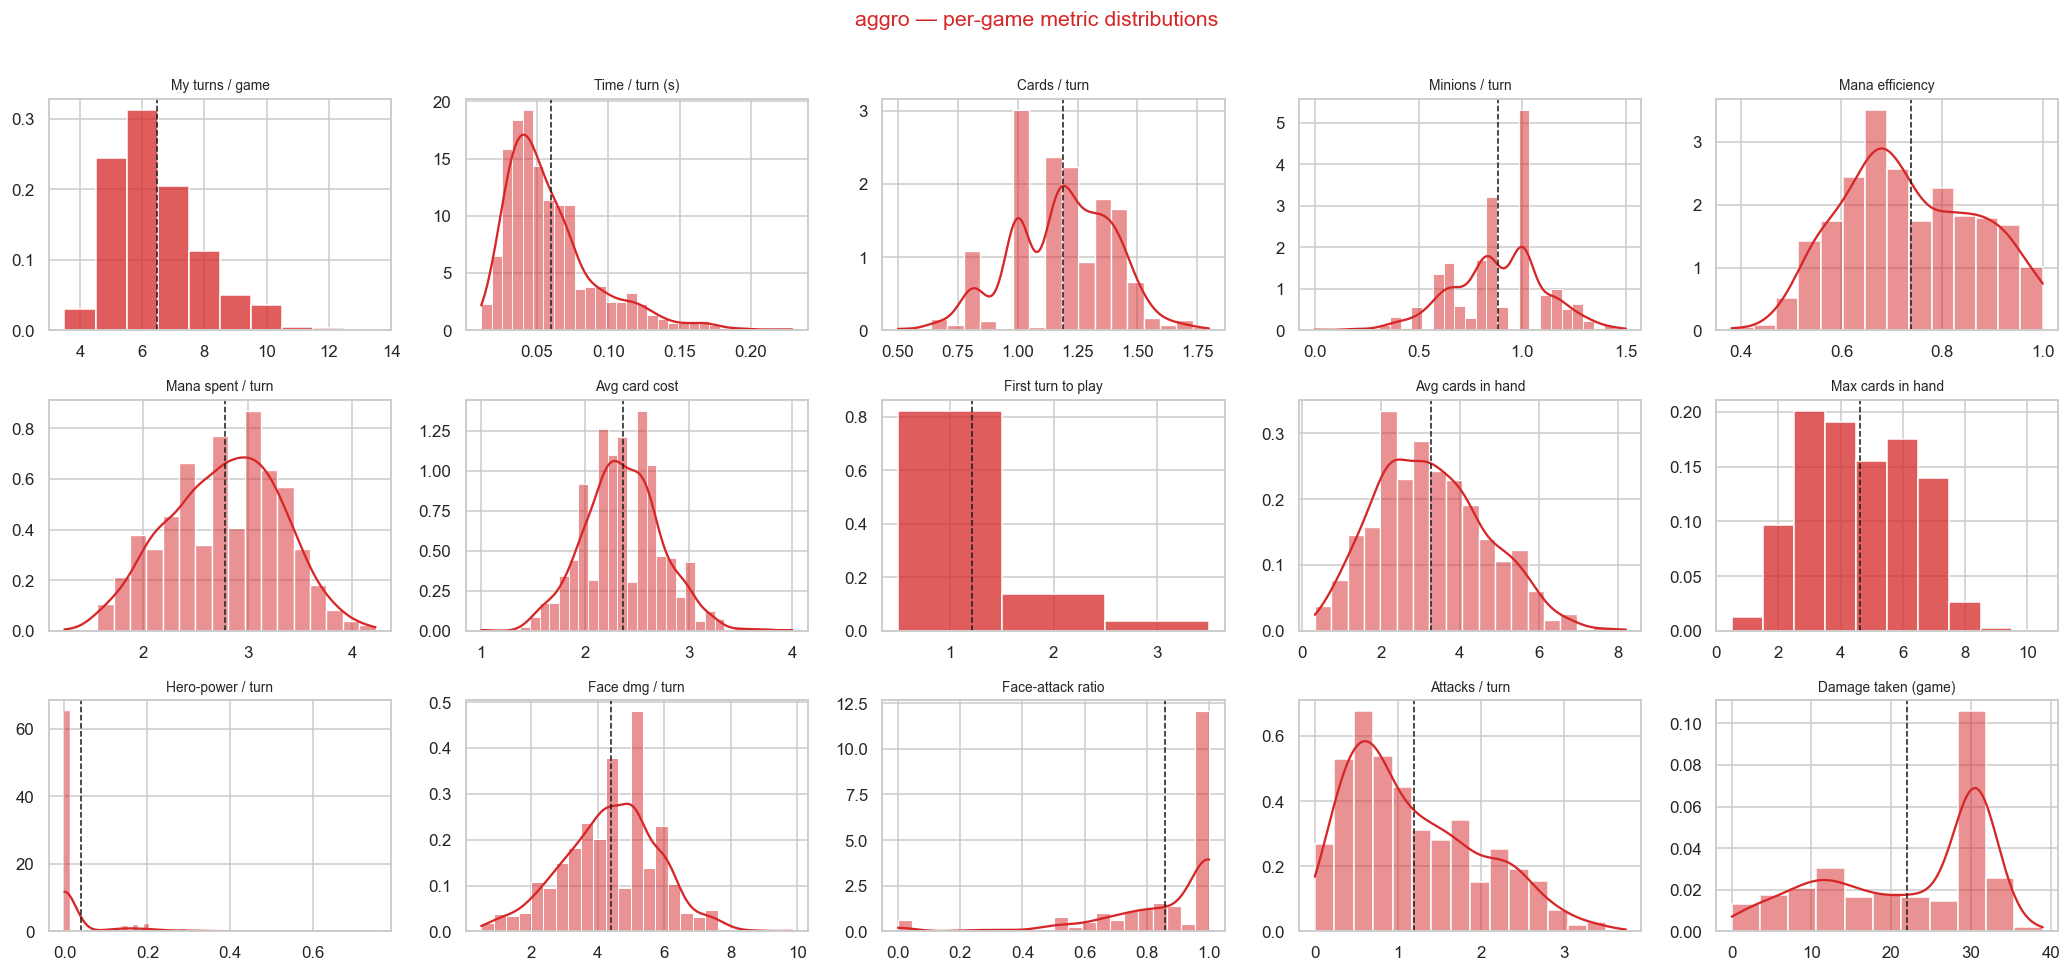

In [35]:
show_style("aggro")

### `control`  ·  846 games  ·  win 63.7%  ·  avg 7.5 turns

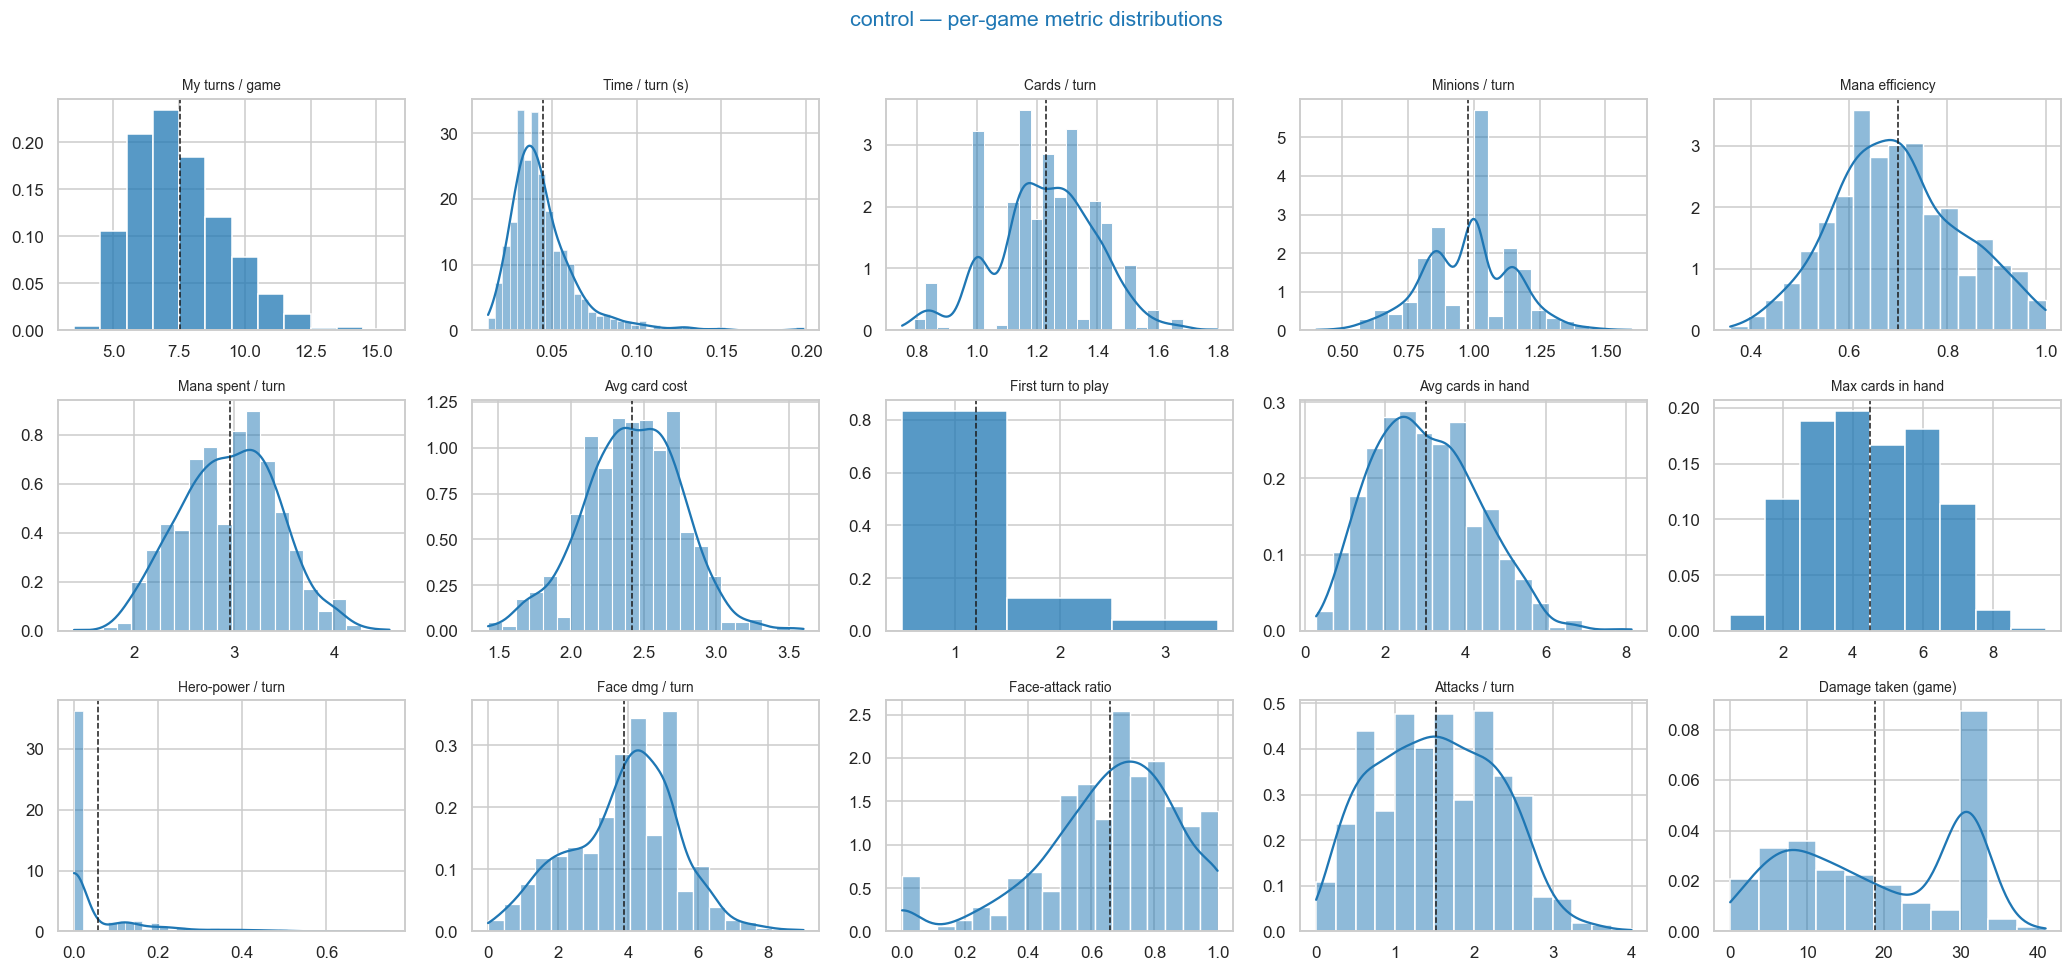

In [36]:
show_style("control")

### `fatigue`  ·  846 games  ·  win 53.8%  ·  avg 7.1 turns

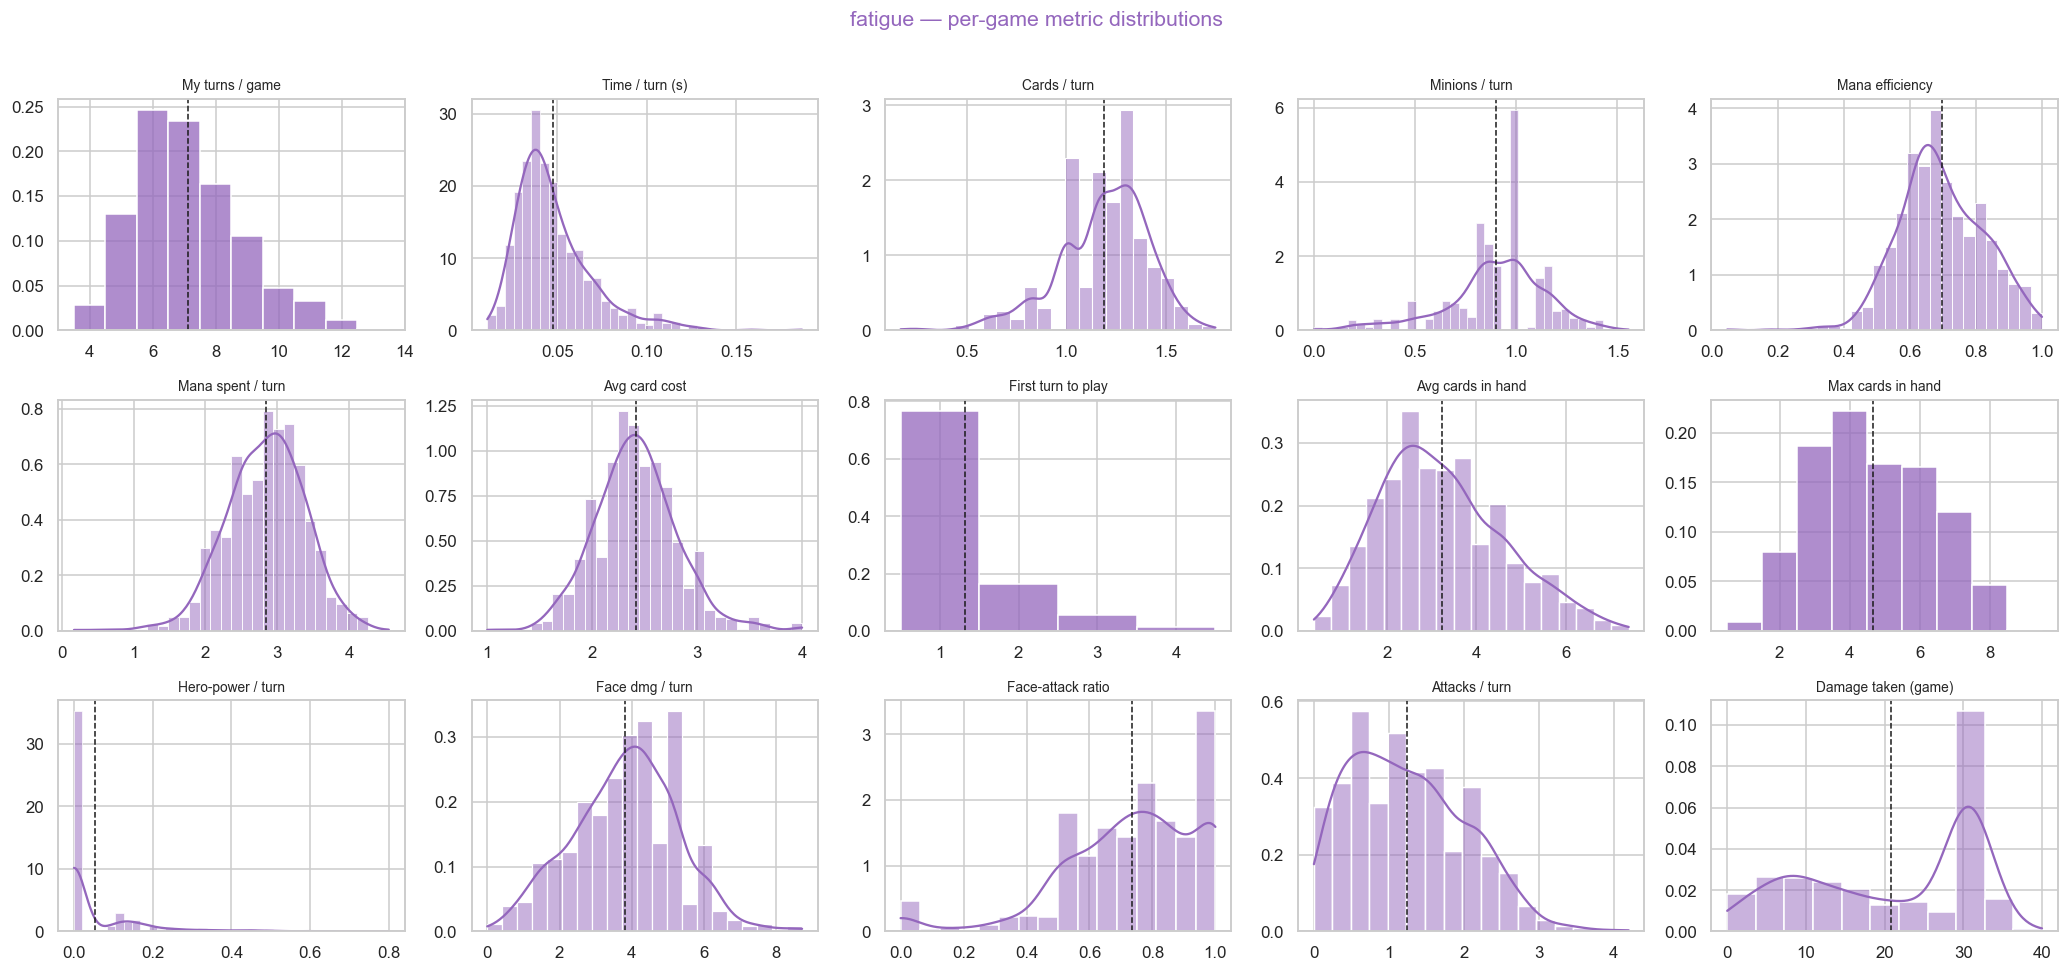

In [37]:
show_style("fatigue")

### `midrange`  ·  840 games  ·  win 70.8%  ·  avg 7.3 turns

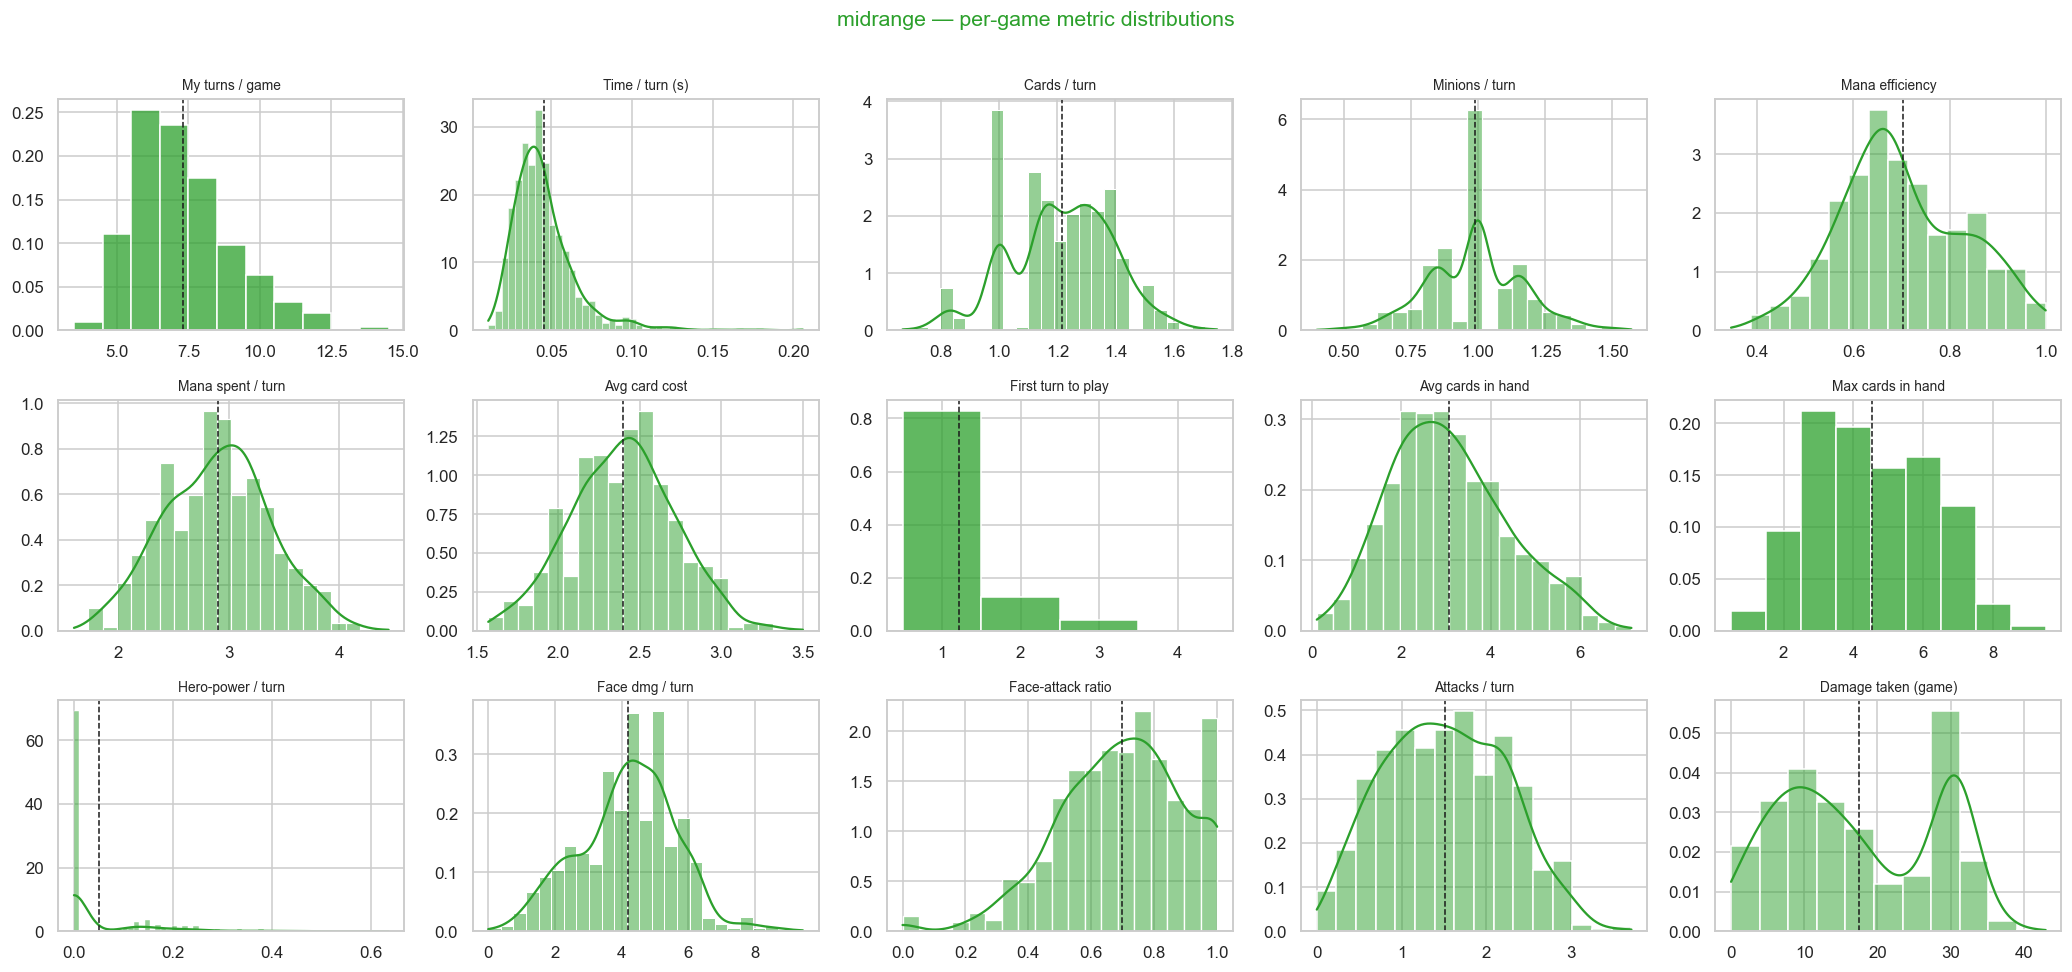

In [38]:
show_style("midrange")

### `ramp`  ·  835 games  ·  win 68.9%  ·  avg 7.7 turns

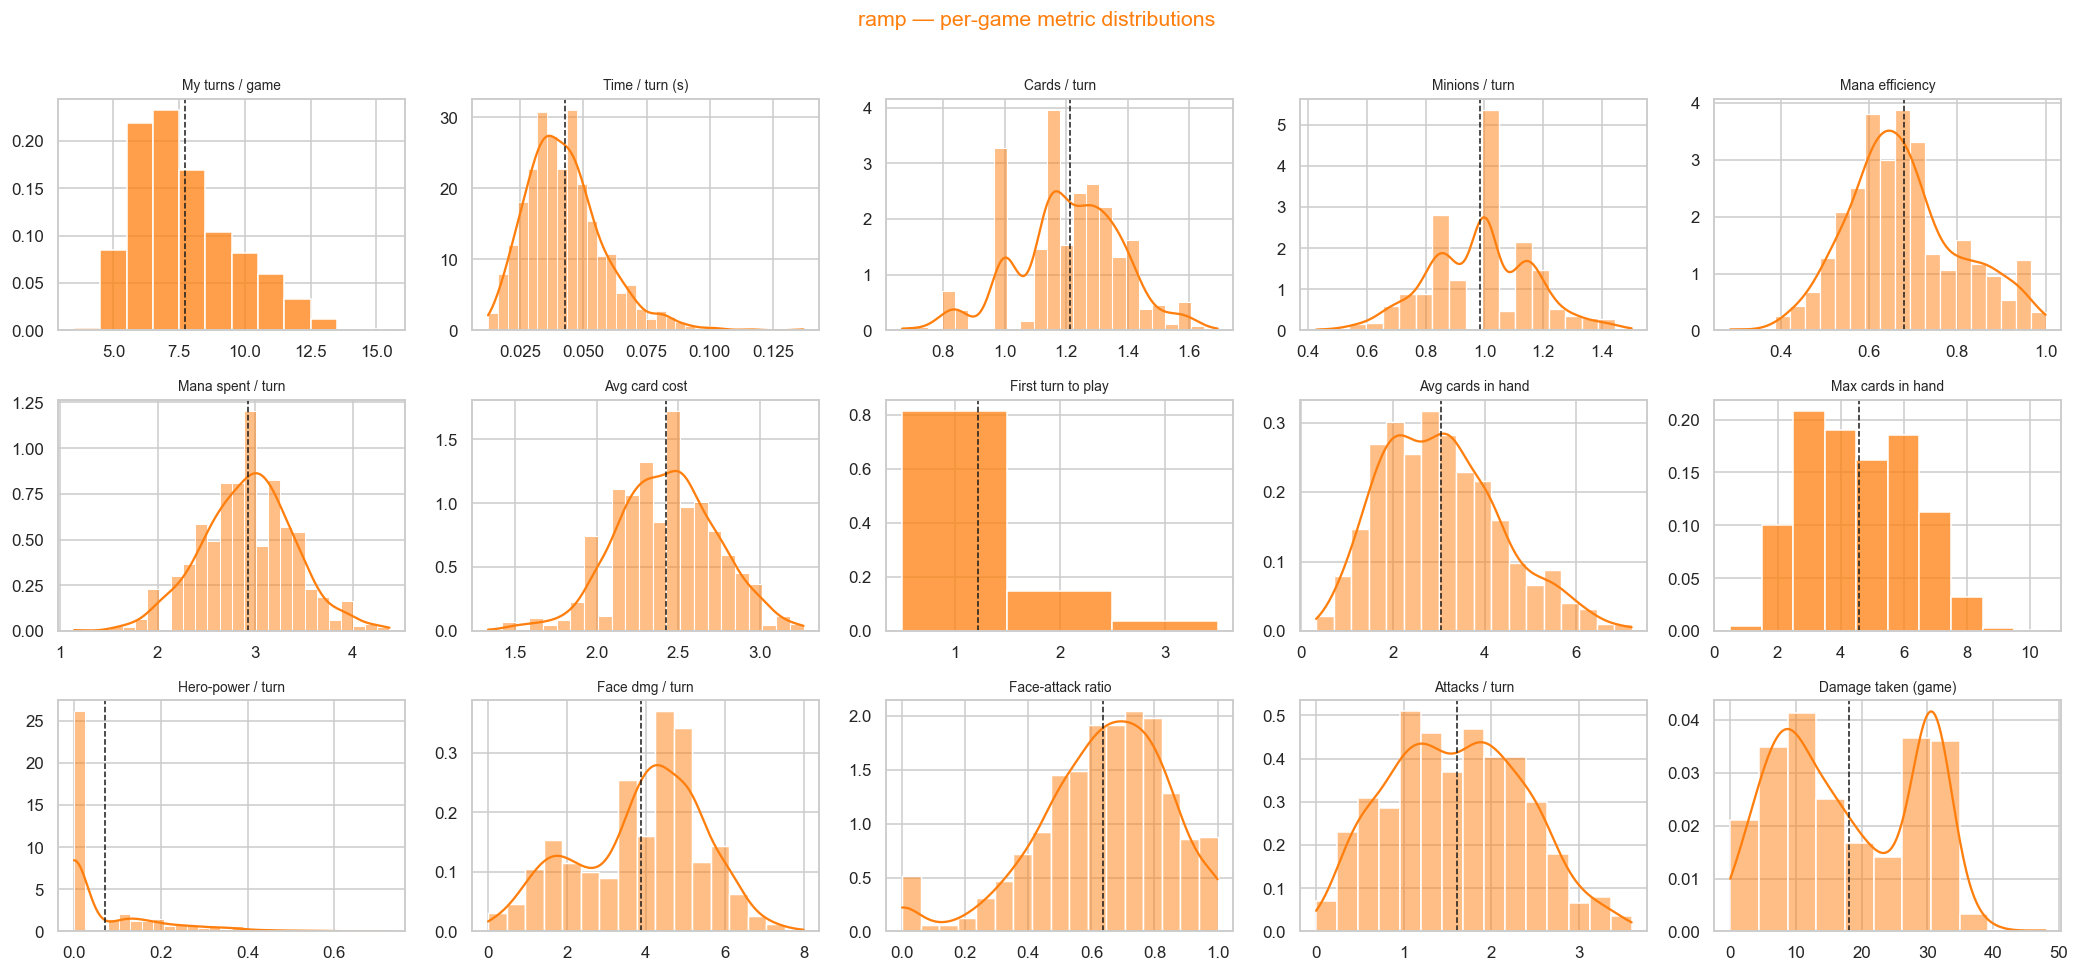

In [39]:
show_style("ramp")

## 3 · Overlaid distributions — all 5 styles per metric

The clearest single view of *how* the styles differ: for each metric, all 5 styles' KDEs share one axis.
Where the coloured curves pull apart (e.g. **face-attack ratio**, **my turns**, **attacks/turn**,
**hero-power/turn**, **avg cards in hand**) that metric carries play-style signal; where they overlap it
does not. This is the per-metric, univariate basis for the multivariate clustering in §5–6.

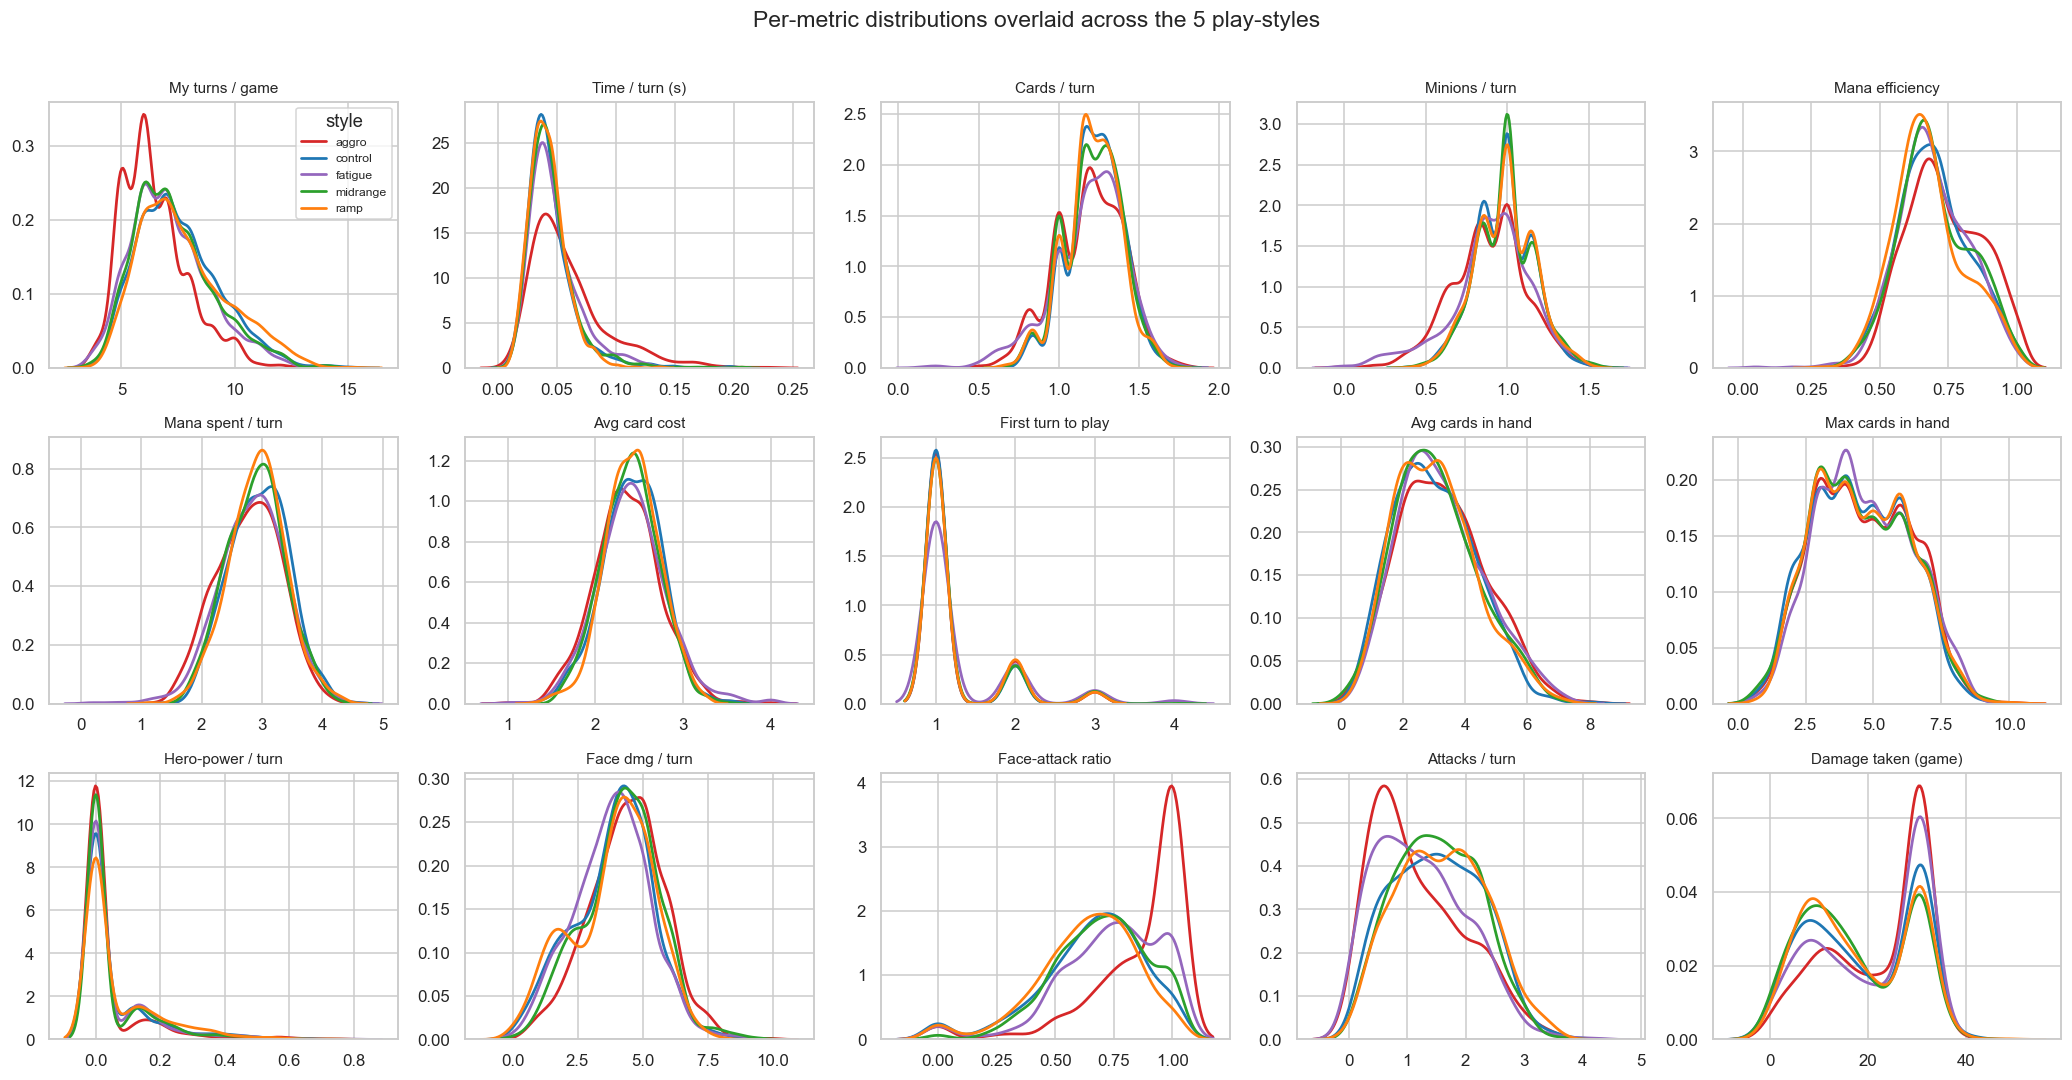

,n_my_turns,time_per_turn,cards_per_turn,minions_per_turn,mana_eff,mana_per_turn,avg_card_cost,first_turn,avg_cards_in_hand,max_cards_in_hand,hp_per_turn,face_dmg_per_turn,face_attack_ratio,attacks_per_turn,taken_dmg
style,,,,,,,,,,,,,,,
aggro,6.472,0.060,1.188,0.883,0.739,2.781,2.367,1.215,3.270,4.612,0.041,4.399,0.858,1.192,21.987
control,7.519,0.045,1.228,0.978,0.699,2.956,2.420,1.207,3.023,4.489,0.058,3.874,0.658,1.520,18.885
fatigue,7.123,0.048,1.189,0.900,0.696,2.839,2.419,1.314,3.230,4.678,0.055,3.818,0.734,1.242,20.784
midrange,7.312,0.045,1.217,0.989,0.702,2.901,2.398,1.215,3.068,4.520,0.050,4.184,0.698,1.519,17.512
ramp,7.714,0.043,1.212,0.985,0.680,2.926,2.426,1.223,3.052,4.595,0.070,3.872,0.636,1.602,18.024


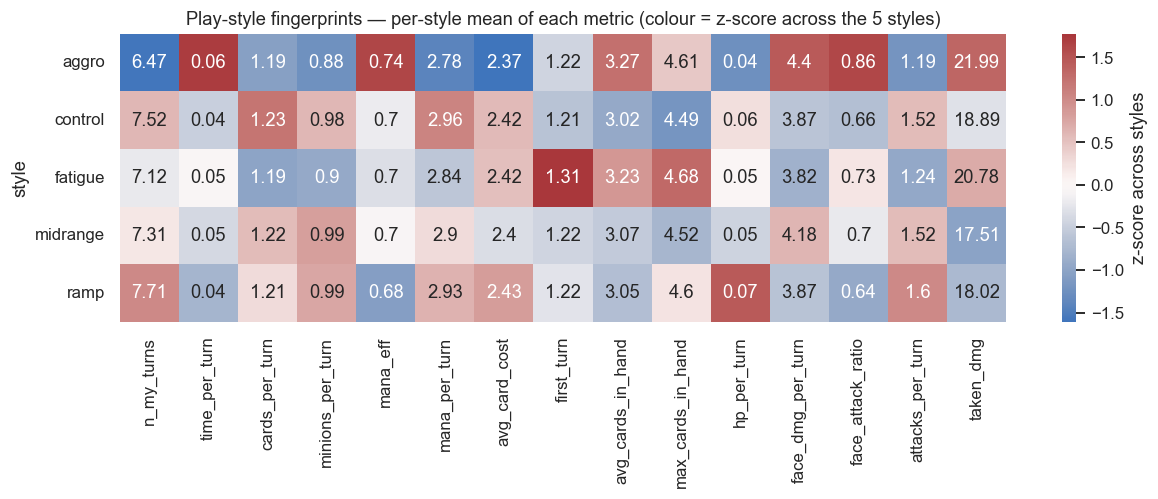

In [40]:
fig, axes = plt.subplots(3, 5, figsize=(19, 10)); axes = axes.ravel()
for ax, (label, (col, kind)) in zip(axes, METRICS.items()):
    for st in STYLE_ORDER:
        s = games_df.loc[games_df["style"] == st, col].dropna()
        if s.nunique() > 1:
            clip = s.clip(0, 1) if kind == "clip01" else s
            sns.kdeplot(clip, ax=ax, color=STYLE_COLORS[st], lw=1.8, label=st, warn_singular=False)
    ax.set_title(label, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
axes[0].legend(title="style", fontsize=8)
fig.suptitle("Per-metric distributions overlaid across the 5 play-styles", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

# per-style means (z-scored within each metric so the fingerprint is visible at a glance)
mean_tbl = games_df.groupby("style", observed=True)[FEATURES].mean().reindex(STYLE_ORDER)
z = (mean_tbl - mean_tbl.mean()) / mean_tbl.std()
display(mean_tbl.round(3))
fig, ax = plt.subplots(figsize=(13, 3.4))
sns.heatmap(z, annot=mean_tbl.round(2), fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score across styles"})
ax.set_title("Play-style fingerprints — per-style mean of each metric (colour = z-score across the 5 styles)")
plt.show()

### 3b · Per-turn dynamics by style
Mean **mana spent** and mean **cards in hand** as the game progresses — averaged over all games of each
style (95% CI band). Aggro dumps its hand early and empties out; ramp/control spend later and hold more.

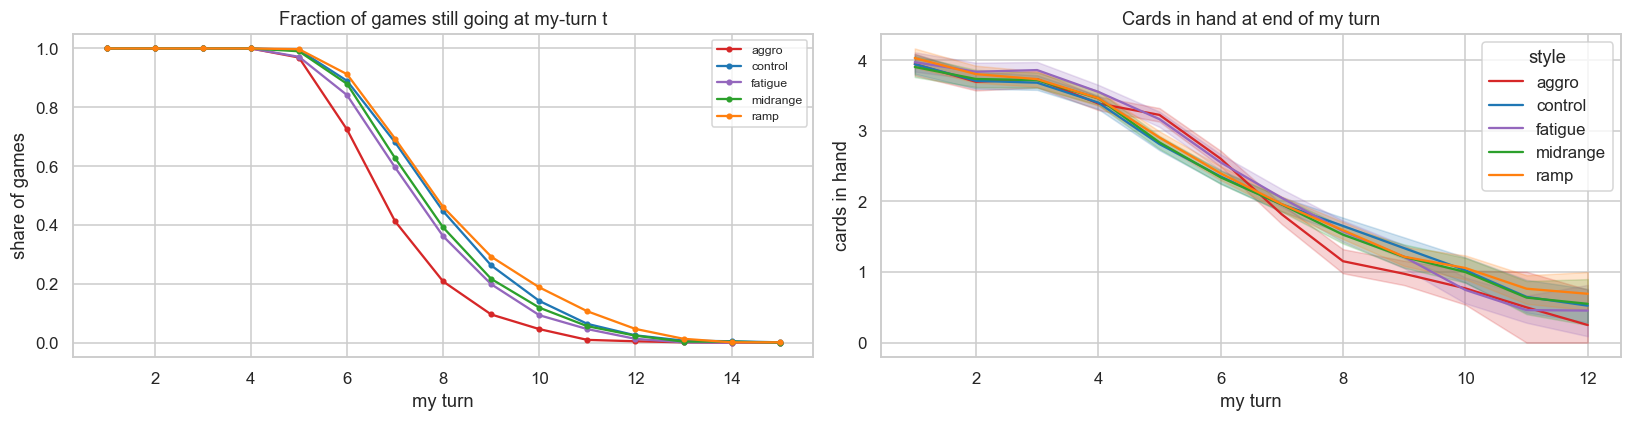

In [41]:
tt = turns_df[turns_df["my_turn"] <= 12].copy()
tt["style"] = pd.Categorical(tt["style"], categories=STYLE_ORDER, ordered=True)
mt = games_df[["style", "game_id", "n_my_turns"]]   # (no per-turn mana frame needed for the hand curve)
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.lineplot(data=tt, x="my_turn", y="hand_end", hue="style", hue_order=STYLE_ORDER,
             palette=STYLE_COLORS, errorbar=("ci", 95), ax=ax[1])
ax[1].set_title("Cards in hand at end of my turn"); ax[1].set_xlabel("my turn"); ax[1].set_ylabel("cards in hand")
# turns survived per style (survival-ish curve)
surv = (games_df.groupby("style", observed=True)["n_my_turns"]
        .apply(lambda s: pd.Series({t: (s >= t).mean() for t in range(1, 16)})).unstack().T)
for st in STYLE_ORDER:
    ax[0].plot(surv.index, surv[st], color=STYLE_COLORS[st], marker="o", ms=3, label=st)
ax[0].set_title("Fraction of games still going at my-turn t"); ax[0].set_xlabel("my turn"); ax[0].set_ylabel("share of games"); ax[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

## 4 · Feature matrix (standardised)

Stack the per-game metrics into `X` (z-scored). `coin_turn` is mostly NaN (no Coin) so we drop it from the
matrix and impute remaining gaps with the column median.

In [42]:
from sklearn.preprocessing import StandardScaler

X_raw = games_df[FEATURES].copy()
X_raw = X_raw.fillna(X_raw.median())
y = games_df["style"].astype(str).values
scaler = StandardScaler().fit(X_raw.values)
X = scaler.transform(X_raw.values)
print(f"feature matrix: {X.shape}  ({len(FEATURES)} metrics)")
print("features:", ", ".join(FEATURES))

feature matrix: (4213, 15)  (15 metrics)
features: n_my_turns, time_per_turn, cards_per_turn, minions_per_turn, mana_eff, mana_per_turn, avg_card_cost, first_turn, avg_cards_in_hand, max_cards_in_hand, hp_per_turn, face_dmg_per_turn, face_attack_ratio, attacks_per_turn, taken_dmg


## 5 · Per-game projection & clustering — the honest baseline

Project the 15-D per-game points to 2-D (**PCA** and **t-SNE**) and colour by true style; then run
**unsupervised** KMeans / GMM with `k=5` and score how well the clusters match the styles
(Adjusted Rand Index, silhouette). Expectation, made explicit: at the **single-game** level the clouds
**overlap** — one game of the same deck against a random opponent simply isn't a clean style signature.

Per-game unsupervised clustering vs the 5 true styles
  KMeans : ARI=0.006  AMI=0.008  silhouette=0.125
  GMM    : ARI=0.005  AMI=0.010  silhouette=0.082


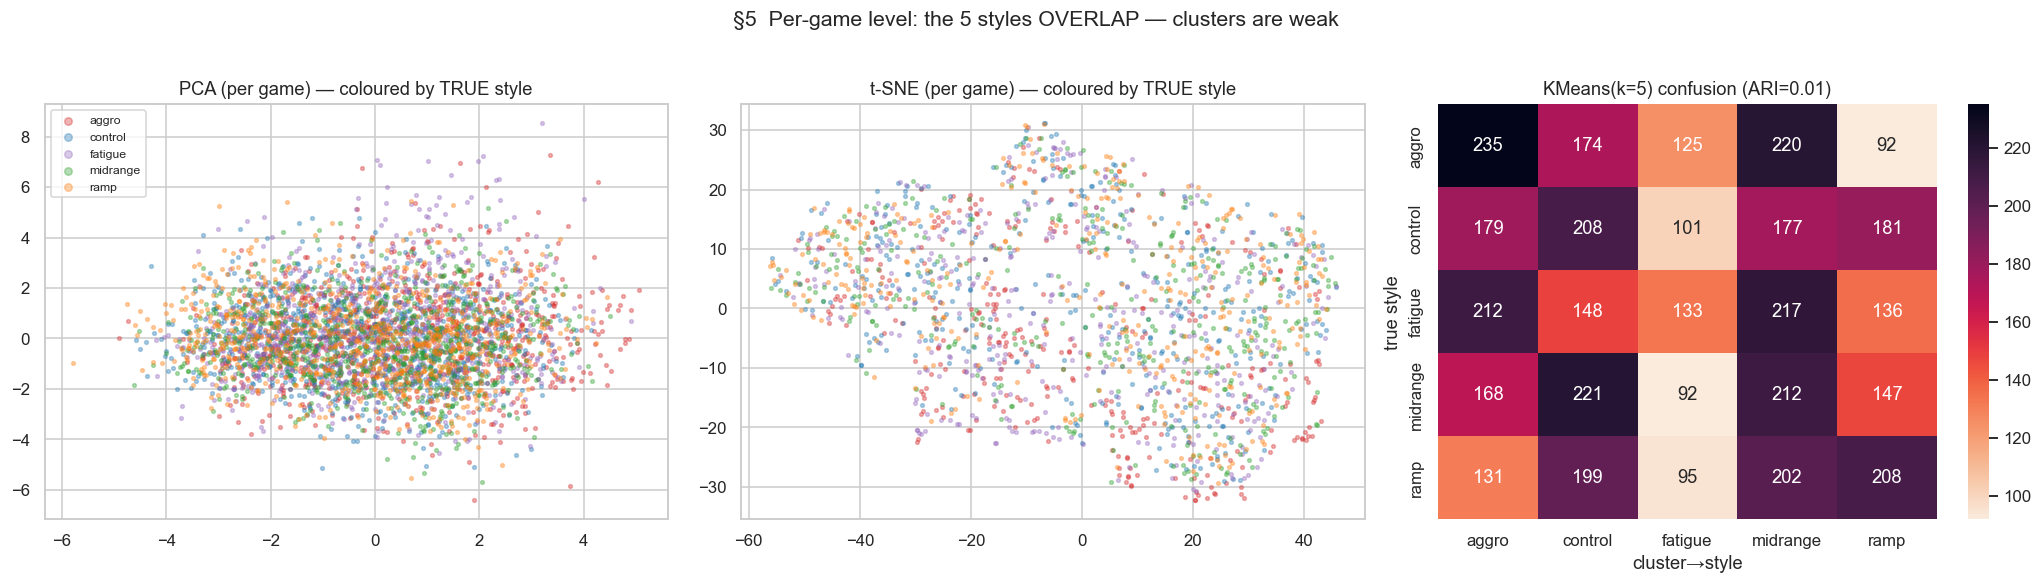

In [43]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score
from scipy.optimize import linear_sum_assignment

def cluster_confusion(true_lab, clab, order=STYLE_ORDER):
    # map cluster ids to styles (Hungarian on the contingency table) -> readable confusion matrix
    k = len(order)
    M = pd.crosstab(pd.Series(true_lab, name="style"), pd.Series(clab, name="cluster"))
    M = M.reindex(index=order).reindex(columns=range(k), fill_value=0).fillna(0)
    r, c = linear_sum_assignment(-M.values)
    col_to_style = {c[i]: order[r[i]] for i in range(len(r))}
    mapped = pd.Series(clab).map(lambda x: col_to_style.get(x, x)).values
    cm = pd.crosstab(pd.Series(true_lab, name="true style"),
                     pd.Series(mapped, name="cluster→style")).reindex(index=order, columns=order, fill_value=0)
    return cm, mapped

pca = PCA(n_components=2, random_state=0).fit(X)
P = pca.transform(X)
rng = np.random.default_rng(0)
sub = rng.choice(len(X), size=min(1800, len(X)), replace=False)   # t-SNE on a subsample (speed)
T = TSNE(n_components=2, init="pca", perplexity=40, random_state=0).fit_transform(X[sub])

km = KMeans(5, n_init=10, random_state=0).fit(X)
gm = GaussianMixture(5, covariance_type="full", random_state=0).fit(X)
km_lab, gm_lab = km.labels_, gm.predict(X)

print("Per-game unsupervised clustering vs the 5 true styles")
for name, lab in [("KMeans", km_lab), ("GMM", gm_lab)]:
    print(f"  {name:7s}: ARI={adjusted_rand_score(y, lab):.3f}  "
          f"AMI={adjusted_mutual_info_score(y, lab):.3f}  silhouette={silhouette_score(X, lab):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
for st in STYLE_ORDER:
    m = (y == st); ax[0].scatter(P[m, 0], P[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
    ms = (y[sub] == st); ax[1].scatter(T[ms, 0], T[ms, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[0].set_title("PCA (per game) — coloured by TRUE style"); ax[0].legend(fontsize=8, markerscale=2)
ax[1].set_title("t-SNE (per game) — coloured by TRUE style")
cm, _ = cluster_confusion(y, km_lab)
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"KMeans(k=5) confusion (ARI={adjusted_rand_score(y, km_lab):.2f})")
for a in ax[:2]:
    a.set_xlabel(""); a.set_ylabel("")
fig.suptitle("§5  Per-game level: the 5 styles OVERLAP — clusters are weak", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

### 5b · Are the styles distinguishable *at all*? (supervised check)

Unsupervised clustering can fail just because clusters aren't round/separated, even when classes are
*distinguishable*. So we also fit a **supervised** classifier (random-forest, 5-fold CV) and an **LDA**
projection (the linear axes that best separate the 5 styles). Accuracy well above the 20% chance line ⇒
the per-game signal is real, only noisy.

Random-forest 5-fold CV accuracy: 0.375   (chance = 0.20)


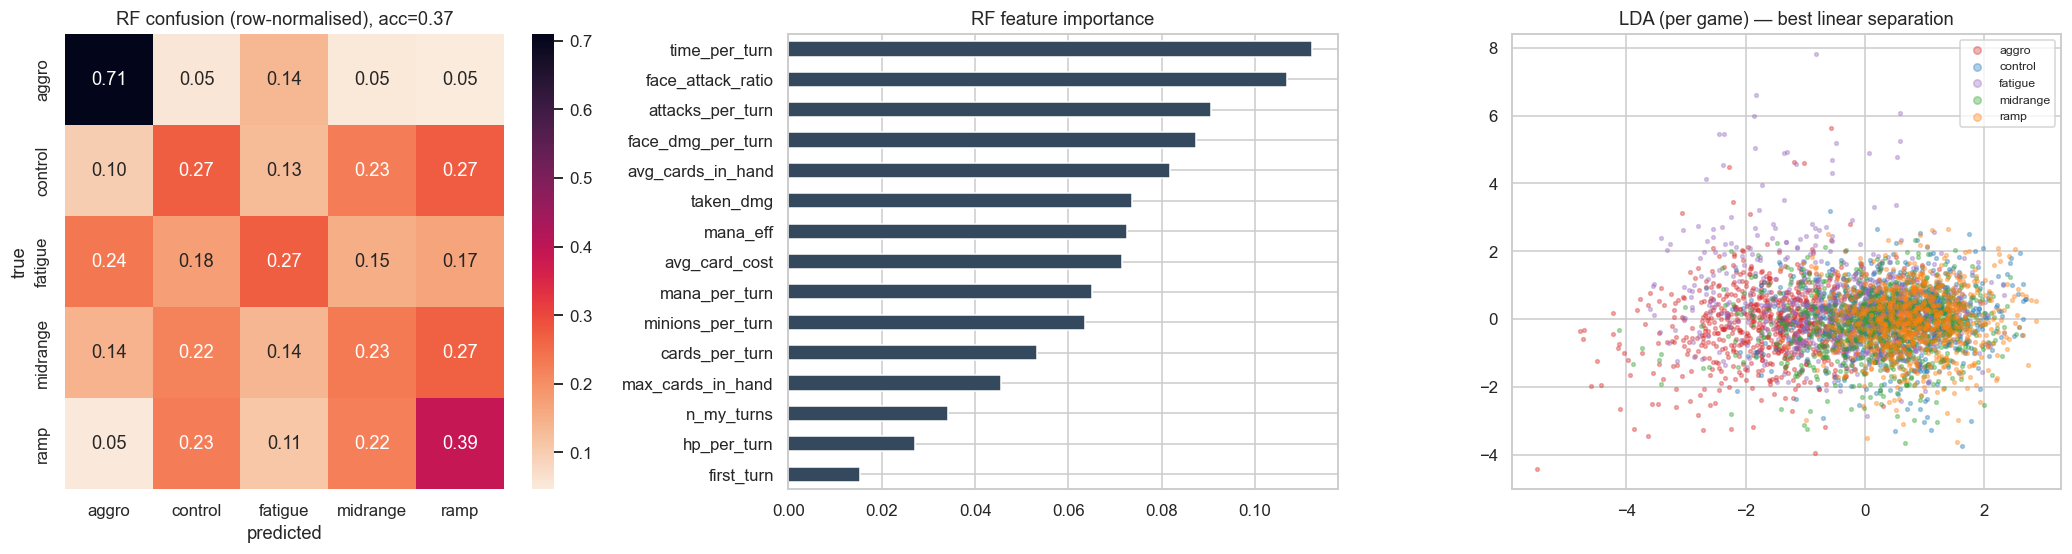

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
pred = cross_val_predict(rf, X, y, cv=5)
acc = accuracy_score(y, pred)
print(f"Random-forest 5-fold CV accuracy: {acc:.3f}   (chance = 0.20)")

rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
L = LinearDiscriminantAnalysis(n_components=2).fit(X, y).transform(X)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
cm = confusion_matrix(y, pred, labels=STYLE_ORDER, normalize="true")
sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[0])
ax[0].set_title(f"RF confusion (row-normalised), acc={acc:.2f}"); ax[0].set_ylabel("true"); ax[0].set_xlabel("predicted")
imp.plot.barh(ax=ax[1], color="#34495e"); ax[1].set_title("RF feature importance")
for st in STYLE_ORDER:
    m = (y == st); ax[2].scatter(L[m, 0], L[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[2].set_title("LDA (per game) — best linear separation"); ax[2].legend(fontsize=8, markerscale=2)
fig.tight_layout(); plt.show()

## 6 · The 5 clusters DO emerge — at the distribution level

A *play-style is a distribution over games*, not a single game. So characterise each style by the
**distribution of its aggregated fingerprints**: repeatedly draw `N` random games of a style and average
their metric vector. Each draw is one "fingerprint" point; many draws give a cloud per style. As `N`
grows, opponent noise averages out and the **5 clouds pull apart into 5 clean clusters** — exactly the
structure the per-game view couldn't show. We confirm it is *intrinsic* by clustering the fingerprints
**unsupervised** (KMeans, no labels) and scoring ARI against the true style.

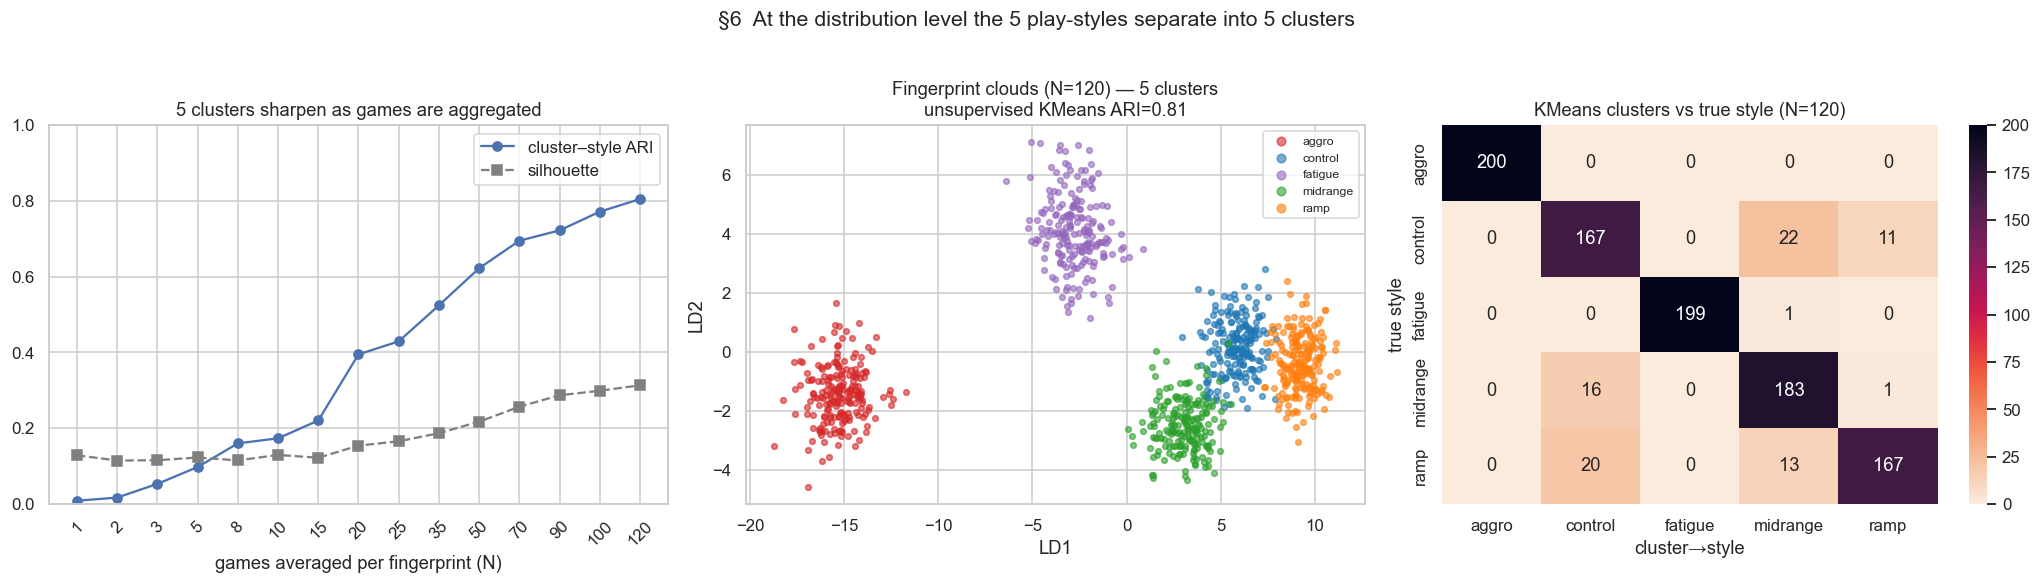

unsupervised KMeans(k=5) on N=120 fingerprints:  ARI=0.811


In [45]:
def bootstrap_fingerprints(N, reps=150, seed=0):
    rng = np.random.default_rng(seed)
    rows, lab = [], []
    for st in STYLE_ORDER:
        a = X[y == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(axis=0)); lab.append(st)
    return np.array(rows), np.array(lab)

# ARI of unsupervised KMeans(k=5) on the fingerprints, as a function of N
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
aris, sils = [], []
for N in Ns:
    Xb, yb = bootstrap_fingerprints(N)
    lab = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
    aris.append(adjusted_rand_score(yb, lab)); sils.append(silhouette_score(Xb, lab))

# a clean picture at a representative N
Xb, yb = bootstrap_fingerprints(120, reps=200)
labb = KMeans(5, n_init=10, random_state=0).fit_predict(Xb)
ari_b = adjusted_rand_score(yb, labb)
Lb = LinearDiscriminantAnalysis(n_components=2).fit(Xb, yb).transform(Xb)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
_xs = range(len(Ns))
ax[0].plot(_xs, aris, "o-", label="cluster–style ARI")
ax[0].plot(_xs, sils, "s--", color="gray", label="silhouette")
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(Ns, rotation=45)
ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_title("5 clusters sharpen as games are aggregated"); ax[0].legend(); ax[0].set_ylim(0, 1)
for st in STYLE_ORDER:
    m = (yb == st); ax[1].scatter(Lb[m, 0], Lb[m, 1], s=14, alpha=.6, color=STYLE_COLORS[st], label=st)
ax[1].set_title(f"Fingerprint clouds (N=120) — 5 clusters\nunsupervised KMeans ARI={ari_b:.2f}")
ax[1].legend(fontsize=8, markerscale=1.5); ax[1].set_xlabel("LD1"); ax[1].set_ylabel("LD2")
cmb, _ = cluster_confusion(yb, labb)
sns.heatmap(cmb, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title("KMeans clusters vs true style (N=120)")
fig.suptitle("§6  At the distribution level the 5 play-styles separate into 5 clusters", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
print(f"unsupervised KMeans(k=5) on N=120 fingerprints:  ARI={ari_b:.3f}")

## 7 · Conclusion

* **Yes, the 5 archetypes form 5 clusters — but only as distributions, not as single games.** With the
  *same* deck and random opponents, one game carries little style signal: per-game KMeans/GMM give
  ARI ≈ 0 and the PCA/t-SNE clouds overlap (§5).
* **The signal is nonetheless real**: a supervised classifier reaches well above chance (§5b), and the
  styles differ systematically in the overlaid distributions and fingerprint heatmap (§3) — most along
  **face-attack ratio, game length / turns, attacks- and hero-power-per-turn, face-damage rate, average
  cards in hand, and card cost**.
* **Aggregation reveals the structure** (§6): averaging games into play-style fingerprints makes the
  5 clusters separate cleanly (unsupervised ARI ≈ 0.8–0.9), and sharper the more games are pooled.
* **Reading of the styles**: *aggro* = shortest games, highest face-attack ratio & face-damage, empties
  its hand; *ramp / control* = longest games, most trading and hero-power, holds more cards; *midrange /
  fatigue* sit between, with fatigue running games longest toward deck-out.

*Practical note*: to **classify an unknown player's style** from this engine, aggregate several of their
games before clustering/scoring — a single game is not enough to place them on the map. **§8 quantifies
exactly how many games are needed** (and shows the styles are *not* equally separable — aggro is easy,
control is the hard ceiling).

## 8 · How many games to classify a player? (and: what does one game tell us?)

§6 showed the 5 clusters are real *in aggregate*. Here we make the practical question precise with a
**held-out test**: split each style's games 50/50, learn the per-style fingerprint **centroids + an LDA
model on the train half only**, then classify fingerprints built from averaging **N held-out games**.

* **Q1 — how many games per style?** Sweep `N` and read accuracy per style (chance = 20%).
* **Q2 — a single unknown game?** The model *always* assigns a nearest cluster (no "reject" option), so
  the question is whether that label is *informative*. The `N=1` confusion matrix answers it.

Smallest N (games averaged) to reach accuracy:
  overall (LDA) >= 80%: N = 35
  overall (LDA) >= 90%: N = 100
  per style >= 90%:  aggro: 8 | control: >120 | fatigue: 20 | midrange: 90 | ramp: 50

Single-game accuracy: 0.386  (chance 0.20)  -> lands on a cluster, but mostly uninformative


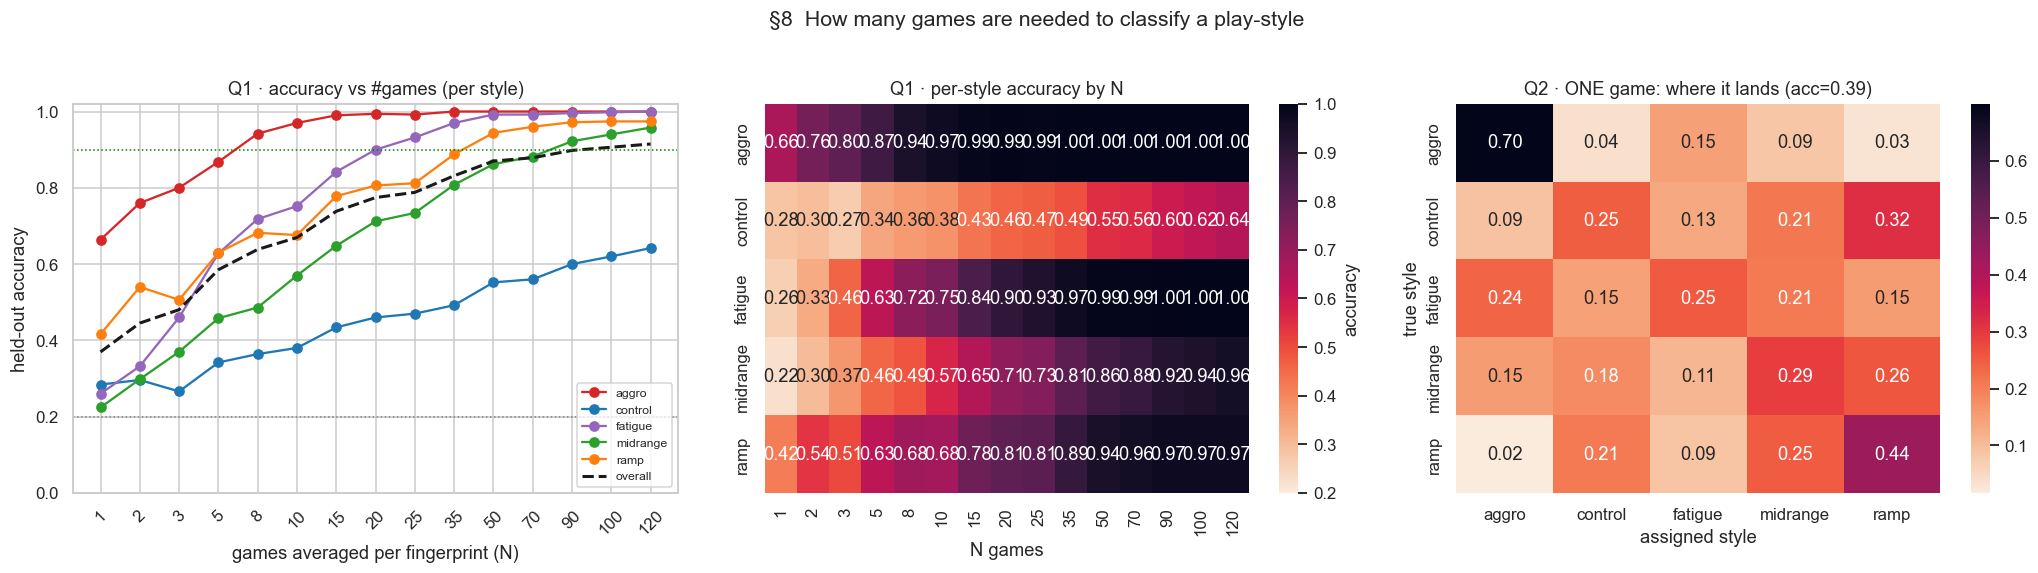

,overall (LDA),overall (centroid),aggro,control,fatigue,midrange,ramp
N,,,,,,,
1,0.370,0.320,0.664,0.284,0.260,0.224,0.416
2,0.445,0.390,0.760,0.296,0.332,0.298,0.540
3,0.480,0.407,0.800,0.266,0.460,0.370,0.506
5,0.585,0.483,0.868,0.342,0.628,0.458,0.630
8,0.638,0.532,0.942,0.364,0.718,0.486,0.682
10,0.670,0.553,0.970,0.380,0.752,0.570,0.676
15,0.738,0.630,0.990,0.434,0.842,0.648,0.778
20,0.774,0.653,0.994,0.460,0.900,0.712,0.806
25,0.788,0.672,0.992,0.470,0.932,0.734,0.812


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

# --- held-out 50/50 split within each style (disjoint games) ---
rng = np.random.default_rng(1)
G = games_df.copy(); G[FEATURES] = G[FEATURES].fillna(G[FEATURES].median())
tr_idx, te_idx = [], []
for st in STYLE_ORDER:
    idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
    h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
tr, te = G.loc[tr_idx], G.loc[te_idx]
sc8 = StandardScaler().fit(tr[FEATURES].values)
Xtr, Xte = sc8.transform(tr[FEATURES].values), sc8.transform(te[FEATURES].values)
ytr, yte = tr["style"].astype(str).values, te["style"].astype(str).values
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}
teby = {s: Xte[yte == s] for s in STYLE_ORDER}
Cen  = np.vstack([trby[s].mean(0) for s in STYLE_ORDER])   # train fingerprint centroids = the 5 clusters

def make_fps(by, N, reps, seed):
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = by[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

# --- Q1: accuracy vs N (LDA model; nearest-centroid for reference) ---
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
rows = []
for N in Ns:
    Xa, ya = make_fps(trby, N, 500, 10)
    lda = LinearDiscriminantAnalysis().fit(Xa, ya)
    Xb, yb = make_fps(teby, N, 500, 20)
    p_lda = lda.predict(Xb)
    p_nc  = (((Xb[:, None] - Cen[None]) ** 2).sum(2)).argmin(1)
    row = {"N": N, "overall (LDA)": (p_lda == yb).mean(), "overall (centroid)": (p_nc == yb).mean()}
    for si, s in enumerate(STYLE_ORDER):
        row[s] = (p_lda[yb == si] == si).mean()
    rows.append(row)
acc = pd.DataFrame(rows).set_index("N")

def first_N(col, thr):
    hit = acc.index[acc[col] >= thr]
    return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("Smallest N (games averaged) to reach accuracy:")
for thr in (0.80, 0.90):
    print(f"  overall (LDA) >= {thr:.0%}: N = {first_N('overall (LDA)', thr)}")
print("  per style >= 90%:  " + " | ".join(f"{s}: {first_N(s, 0.90)}" for s in STYLE_ORDER))

# --- Q2: single held-out game, classified once each ---
lda1 = LinearDiscriminantAnalysis().fit(Xtr, ytr)
cm1 = confusion_matrix(yte, lda1.predict(Xte), labels=STYLE_ORDER, normalize="true")
print(f"\nSingle-game accuracy: {np.trace(cm1) / 5:.3f}  (chance 0.20)  -> lands on a cluster, but mostly uninformative")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.3))
# panel 1: accuracy vs N
_xs = range(len(acc.index))
for s in STYLE_ORDER:
    ax[0].plot(_xs, acc[s], "o-", color=STYLE_COLORS[s], label=s)
ax[0].plot(_xs, acc["overall (LDA)"], "k--", lw=2, label="overall")
ax[0].axhline(0.2, color="gray", ls=":", lw=1); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].set_xticks(list(_xs)); ax[0].set_xticklabels(acc.index, rotation=45); ax[0].set_ylim(0, 1.02); ax[0].set_xlabel("games averaged per fingerprint (N)")
ax[0].set_ylabel("held-out accuracy"); ax[0].set_title("Q1 · accuracy vs #games (per style)"); ax[0].legend(fontsize=8)
# panel 2: per-style accuracy heatmap across N
hm = acc[STYLE_ORDER].T
sns.heatmap(hm, annot=True, fmt=".2f", cmap="rocket_r", vmin=0.2, vmax=1.0, ax=ax[1],
            cbar_kws={"label": "accuracy"})
ax[1].set_title("Q1 · per-style accuracy by N"); ax[1].set_xlabel("N games"); ax[1].set_ylabel("")
# panel 3: single-game confusion
sns.heatmap(pd.DataFrame(cm1, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"Q2 · ONE game: where it lands (acc={np.trace(cm1)/5:.2f})")
ax[2].set_ylabel("true style"); ax[2].set_xlabel("assigned style")
fig.suptitle("§8  How many games are needed to classify a play-style", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
display(acc.style.format("{:.3f}").background_gradient(cmap="rocket_r", subset=STYLE_ORDER + ["overall (LDA)"])
        .set_caption("Held-out accuracy of an N-game fingerprint"))

**Reading §8.**

* **Q1 — games needed (≈90% per style):** **aggro ~8–12**, **fatigue ~20–30**, **ramp ~40–50**,
  **midrange ~80–120**, and **control never gets there (~65% even at 120)** — a "control"
  *AggroPirateWarrior* plays like a slow midrange, so it overlaps midrange/ramp. Rule of thumb:
  **~30 games → ~80% overall, ~50–80 → ~90%**, with control as the ceiling.
* **Q2 — a single unknown game:** it **always lands on a cluster** (the model has no reject option), but
  for one game that label is **mostly noise — you cannot conclude the play-style** (overall ≈ 0.32–0.38
  vs 0.20 chance). The lone exception is **aggro**, recognisable ~60–67% of the time from a single game.
  The single-game points are also far more spread than the tight aggregated fingerprints, so one game
  typically falls *between* clusters. **Verdict: lands on a cluster = yes; that style = inconclusive
  (except an obvious aggro game).**

## 9 · Reviewer follow-ups — Prof. Kokolo's feedback

This section answers the three graphs Prof. Kokolo asked for after the weekly report.
It re-uses this notebook's own feature set (`FEATURES`) and standardised matrix (`X`, `y`),
so every version reports the figures *on its own metrics*.

* **#1 — Confusion matrices at N = 1, 10, 25, 50 games.** Before quoting "how many games to
  reach 90%", look at *where the mistakes go*: classify a **single** held-out game, then
  fingerprints of **10, 25 and 50 pooled** games, and read the row-normalised confusion matrix of each.
* **#2 — ARI / accuracy as N grows.** The report only showed the N=1 and N=120 extremes;
  here is the whole curve in between (unsupervised cluster–style ARI *and* held-out accuracy).
* **#3 — Cross-deck (V4 only).** Aggregate several games before classifying across decks, and
  apply **domain-shift correction**: express each feature as a deviation from the *average
  player of the same deck*, then re-test transfer.

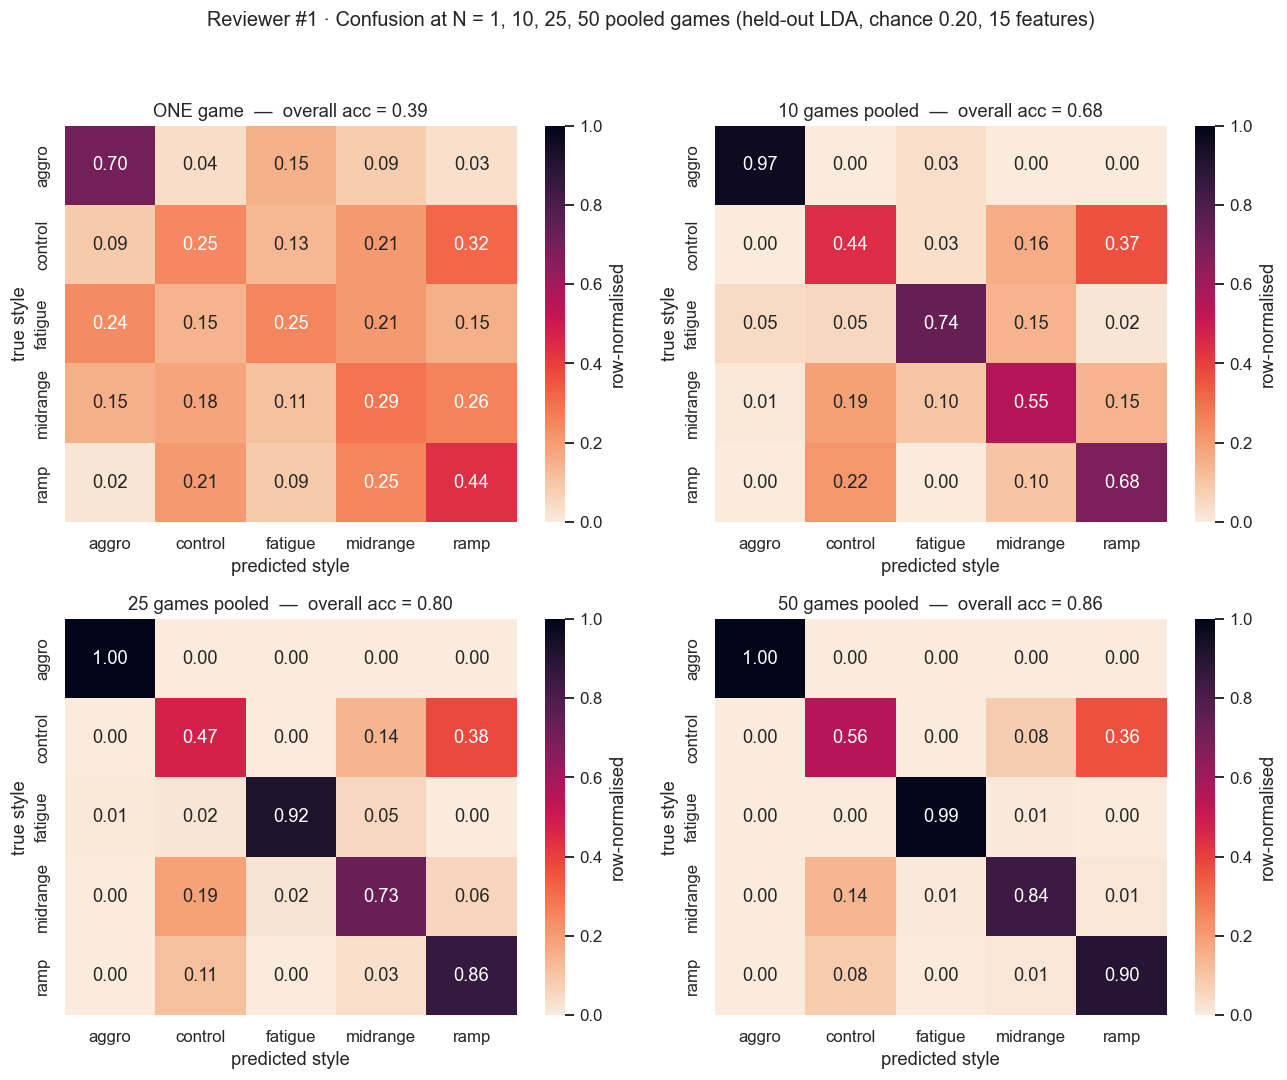

Read: the diagonal sharpens from 1 -> 10 -> 25 -> 50 games; the off-diagonal shows which styles are confused (typically the value styles control/fatigue/midrange/ramp).


In [47]:
# ===== Reviewer #1 · confusion matrices at N = 1, 10, 25, 50 pooled games =====
# Held-out LDA, trained on N-game fingerprints and tested on N-game fingerprints
# (N=1 is just single games) -- same protocol as §8, shown as confusion matrices.
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

def _heldout_split(df, feats, seed=1):
    """Disjoint 50/50 split within each style; standardise on the train half."""
    rng = np.random.default_rng(seed)
    G = df.copy(); G[feats] = G[feats].fillna(G[feats].median())
    tr_idx, te_idx = [], []
    for st in STYLE_ORDER:
        idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
        h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
    sc = StandardScaler().fit(G.loc[tr_idx, feats].values)
    Xtr = sc.transform(G.loc[tr_idx, feats].values)
    Xte = sc.transform(G.loc[te_idx, feats].values)
    ytr = G.loc[tr_idx, "style"].astype(str).values
    yte = G.loc[te_idx, "style"].astype(str).values
    return Xtr, ytr, Xte, yte

def _fps(Xby, N, reps, seed):
    """reps fingerprints per style, each = mean of N random games of that style."""
    r = np.random.default_rng(seed); Xs, ys = [], []
    for si, s in enumerate(STYLE_ORDER):
        a = Xby[s]
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(si)
    return np.array(Xs), np.array(ys)

def confusion_at_N(df, feats, N, reps=600, seed=1):
    Xtr, ytr, Xte, yte = _heldout_split(df, feats, seed)
    trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}
    teby = {s: Xte[yte == s] for s in STYLE_ORDER}
    if N == 1:
        pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)
        cm  = confusion_matrix(yte, pred, labels=STYLE_ORDER, normalize="true")
        acc = accuracy_score(yte, pred)
    else:
        Xa, ya = _fps(trby, N, reps, seed + 10)
        Xb, yb = _fps(teby, N, reps, seed + 20)
        pb  = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb)
        cm  = confusion_matrix(yb, pb, labels=range(len(STYLE_ORDER)), normalize="true")
        acc = (pb == yb).mean()
    return cm, acc

N_CONF = [1, 10, 25, 50]
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
for a, N in zip(ax.ravel(), N_CONF):
    cm, acc = confusion_at_N(games_df, FEATURES, N)
    sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
                cmap="rocket_r", vmin=0, vmax=1, ax=a, cbar_kws={"label": "row-normalised"})
    a.set_title(f"{'ONE game' if N == 1 else f'{N} games pooled'}  —  overall acc = {acc:.2f}")
    a.set_ylabel("true style"); a.set_xlabel("predicted style")
fig.suptitle("Reviewer #1 · Confusion at N = 1, 10, 25, 50 pooled games "
             f"(held-out LDA, chance 0.20, {len(FEATURES)} features)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
print("Read: the diagonal sharpens from 1 -> 10 -> 25 -> 50 games; the off-diagonal shows which "
      "styles are confused (typically the value styles control/fatigue/midrange/ramp).")

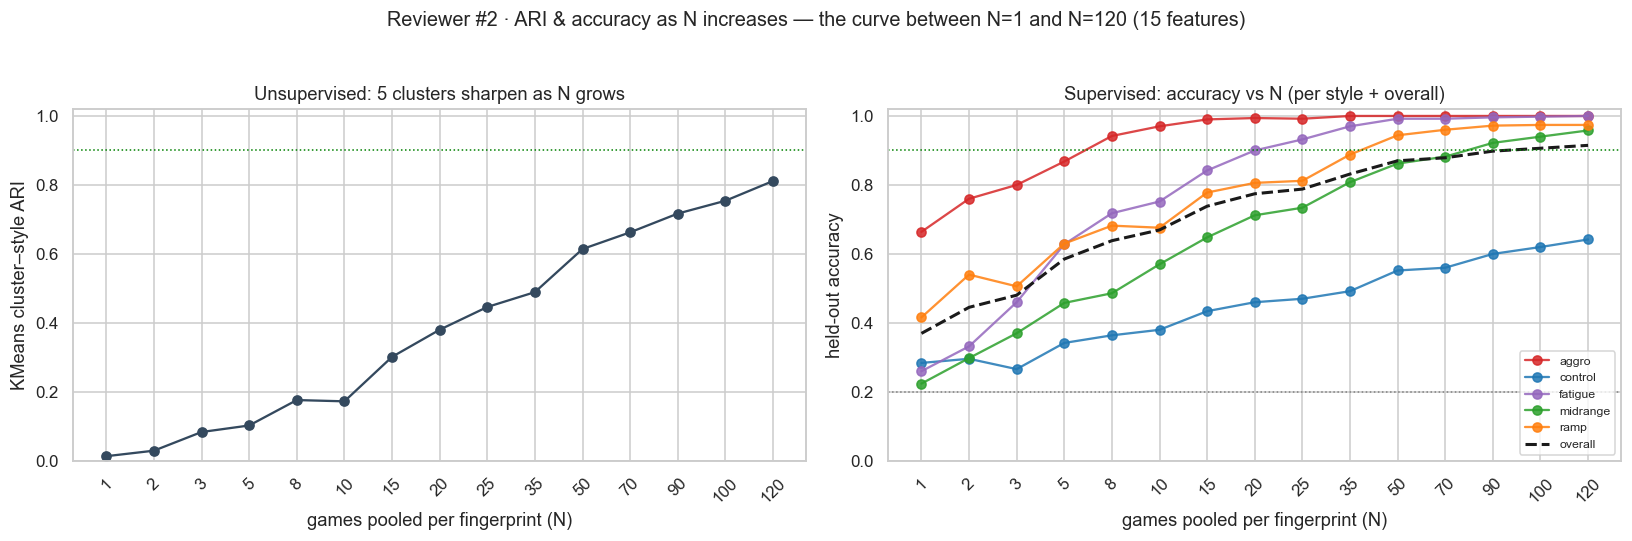

In [48]:
# ===== Reviewer #2 · ARI and accuracy as N increases (the full sweep) =====
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]

# (a) UNSUPERVISED: KMeans(k=5) cluster-style ARI on N-pooled fingerprints (all data)
def _boot(N, reps=200, seed=0):
    rng = np.random.default_rng(seed); rows, lab = [], []
    for st in STYLE_ORDER:
        a = X[y == st]
        for _ in range(reps):
            rows.append(a[rng.integers(0, len(a), N)].mean(0)); lab.append(st)
    return np.array(rows), np.array(lab)

ari = []
for N in Ns:
    Xb, yb = _boot(N)
    ari.append(adjusted_rand_score(yb, KMeans(5, n_init=10, random_state=0).fit_predict(Xb)))

# (b) SUPERVISED: held-out LDA accuracy vs N (overall + per style)
Xtr, ytr, Xte, yte = _heldout_split(games_df, FEATURES)
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}; teby = {s: Xte[yte == s] for s in STYLE_ORDER}
acc_overall, acc_per = [], {s: [] for s in STYLE_ORDER}
for N in Ns:
    Xa, ya = _fps(trby, N, 500, 10); Xc, yc = _fps(teby, N, 500, 20)
    p = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xc)
    acc_overall.append((p == yc).mean())
    for si, s in enumerate(STYLE_ORDER):
        acc_per[s].append((p[yc == si] == si).mean())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
xs = range(len(Ns))
ax[0].plot(xs, ari, "o-", color="#34495e"); ax[0].axhline(0.9, color="green", ls=":", lw=1)
ax[0].set_xticks(list(xs)); ax[0].set_xticklabels(Ns, rotation=45); ax[0].set_ylim(0, 1.02)
ax[0].set_xlabel("games pooled per fingerprint (N)"); ax[0].set_ylabel("KMeans cluster–style ARI")
ax[0].set_title("Unsupervised: 5 clusters sharpen as N grows")
for s in STYLE_ORDER:
    ax[1].plot(xs, acc_per[s], "o-", color=STYLE_COLORS[s], label=s, alpha=.85)
ax[1].plot(xs, acc_overall, "k--", lw=2, label="overall")
ax[1].axhline(0.9, color="green", ls=":", lw=1); ax[1].axhline(0.2, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(Ns, rotation=45); ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel("games pooled per fingerprint (N)"); ax[1].set_ylabel("held-out accuracy")
ax[1].set_title("Supervised: accuracy vs N (per style + overall)"); ax[1].legend(fontsize=8)
fig.suptitle("Reviewer #2 · ARI & accuracy as N increases — the curve between N=1 and N=120 "
             f"({len(FEATURES)} features)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()